In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [4]:
df=pd.read_csv("train (1).csv")
df.tail()

,1.126727,47.743884
64,-1.500082,414.076341
65,0.493507,-34.616994
66,1.725494,573.001536
67,0.872540,18.485251
68,0.725811,-16.120312


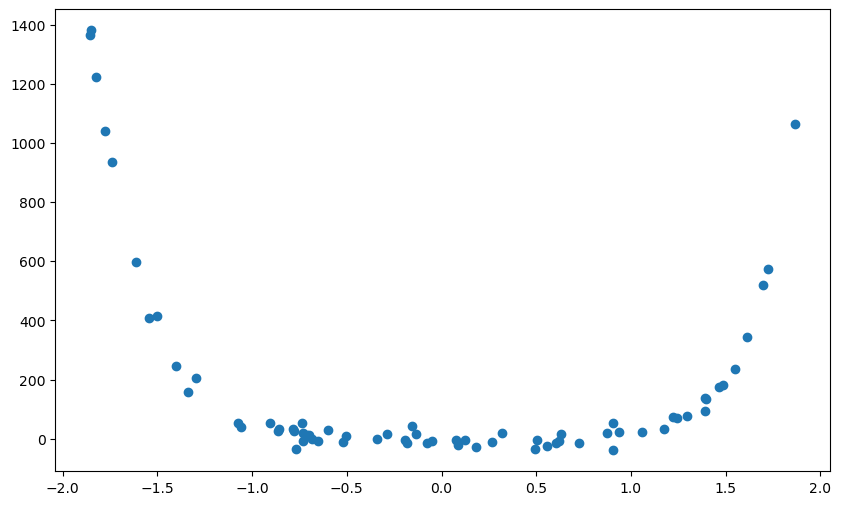

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.show()

In [24]:
#Polynomial Regression
X=df.iloc[:, 0].values.reshape(-1,1)
y=df.iloc[:, 1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for degree in range(4, 12):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)
    r2 = model.score(X_test_poly, y_test)
    adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test_poly.shape[1] - 1)
    print(f"Degree: {degree}, Adjusted R^2: {adjusted_r2}")

Degree: 4, Adjusted R^2: 0.9757662151731152
Degree: 5, Adjusted R^2: 0.9719239996008792
Degree: 6, Adjusted R^2: 0.9975825225124966
Degree: 7, Adjusted R^2: 0.9955457056679015
Degree: 8, Adjusted R^2: 0.9970526069110865
Degree: 9, Adjusted R^2: 0.9963849897123893
Degree: 10, Adjusted R^2: 0.9887956123843953
Degree: 11, Adjusted R^2: 0.9762778642421744


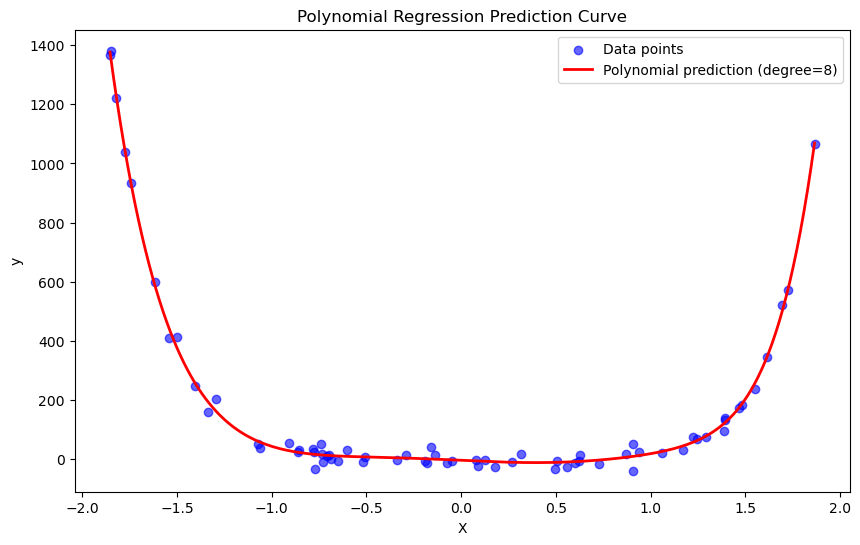

In [20]:
# Plot polynomial prediction using the best degree found from the validation curve (or default degree 7)
best_degree = 8

poly_plot = PolynomialFeatures(degree=best_degree)
X_plot_poly = poly_plot.fit_transform(X)
model_plot = LinearRegression()
model_plot.fit(X_plot_poly, y)

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_plot = model_plot.predict(poly_plot.transform(X_plot))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data points')
plt.plot(X_plot, y_plot, color='red', linewidth=2, label=f'Polynomial prediction (degree={best_degree})')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Prediction Curve')
plt.legend()
plt.show()

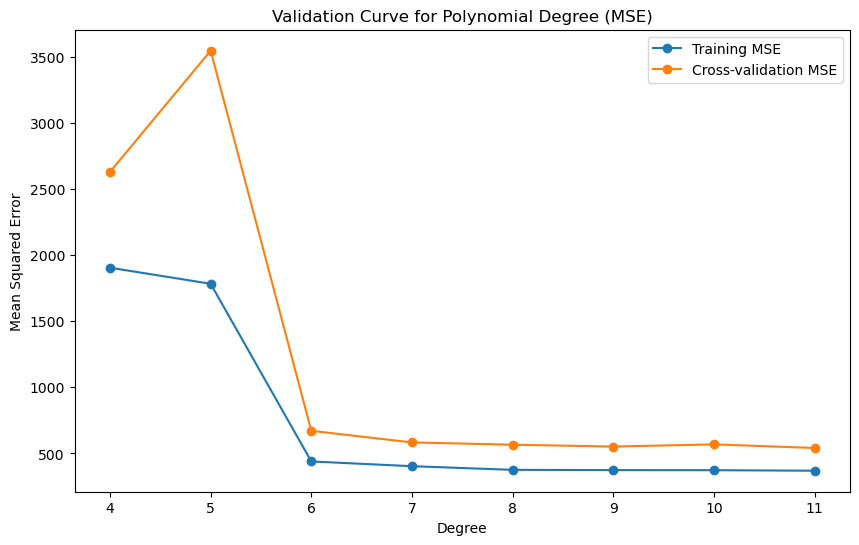

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import validation_curve

pipe = Pipeline([
    ('poly', PolynomialFeatures()),
    ('linreg', LinearRegression())
])

degree_range = np.arange(4, 12)
train_scores, test_scores = validation_curve(
    pipe,
    X,
    y.ravel(),
    param_name='poly__degree',
    param_range=degree_range,
    cv=5,
    scoring='neg_mean_squared_error'
)

train_mse = -np.mean(train_scores, axis=1)
test_mse = -np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(degree_range, train_mse, marker='o', label='Training MSE')
plt.plot(degree_range, test_mse, marker='o', label='Cross-validation MSE')
plt.xlabel('Degree')
plt.ylabel('Mean Squared Error')
plt.title('Validation Curve for Polynomial Degree (MSE)')
plt.legend()
plt.show()

In [21]:
dt=pd.read_csv("test.csv")
dt.head()

,-1.819228,1255.525442
0,0.349282,18.559193
1,0.442694,-2.665981
2,0.044696,-3.456760
3,1.419504,131.568324
4,-0.577323,34.867037


In [ ]:
x = dt.iloc[:, 0].values.reshape(-1, 1)
y = dt.iloc[:, 1].values

y_pred = model_plot.predict(poly_plot.transform(x))
r2 = model_plot.score(poly_plot.transform(x), y)
print(f"R^2 on test data: {r2}")


R^2 on test data: 0.996188156323907
